# PixelCNN原理概述（详细版）

PixelCNN（Pixel Convolutional Neural Network）是经典的**自回归图像生成模型**。它的核心思想是：把一张图像看作像素序列，按固定顺序（通常是从上到下、从左到右）逐个建模每个像素的条件分布。

## 1. 概率建模目标
对于图像 $\mathbf{x}$，PixelCNN 建模联合分布：

$$
p(\mathbf{x}) = \prod_{i=1}^{H}\prod_{j=1}^{W} p(x_{i,j}\mid x_{<i,j})
$$

其中 $x_{<i,j}$ 表示在扫描顺序中位于像素 $(i,j)$ 之前的所有像素。

如果像素被离散为 $K$ 个等级（例如灰度 8 级、16 级、256 级），则模型在每个位置输出一个 $K$ 维分类分布。

## 2. 为什么要用掩码卷积
普通卷积会同时看到“过去像素”和“未来像素”，这会破坏自回归约束（信息泄漏）。

因此 PixelCNN 使用 Masked Convolution：
- **Type A 掩码**：首层使用，不允许看当前像素，只看严格过去像素。
- **Type B 掩码**：后续层使用，允许看当前像素特征，但仍不能看未来像素。

这样既能保持卷积并行训练优势，又能保证概率分解的因果性。

## 3. 训练目标
训练时使用真实图像作为输入，预测每个像素的离散类别，损失函数是逐像素交叉熵：

$$
\mathcal{L} = -\sum_{i,j} \log p_\theta(x_{i,j}^{\text{gt}}\mid x_{<i,j})
$$

特点：
- 训练阶段可并行计算所有位置（因为输入是真实图像）；
- 采样阶段必须逐像素生成（因为后续像素依赖前面采样结果）。

## 4. PixelCNN的优势与局限
**优势**：
- 概率建模严格、可解释性强；
- 训练稳定，不依赖对抗博弈；
- 可直接计算对数似然。

**局限**：
- 采样慢（逐像素、串行）；
- 对高分辨率图像成本高；
- 早期版本在长程依赖建模上有限（后续由更深结构、门控结构改进）。

## 5. 与本Notebook代码对应关系
- `MaskConv2d`：实现 Type A / Type B 掩码卷积；
- `ResidualBlock`：提升表达能力和训练深度；
- `PixelCNN`：堆叠掩码卷积 + 残差块 + 1x1 输出头，输出每像素类别分布。

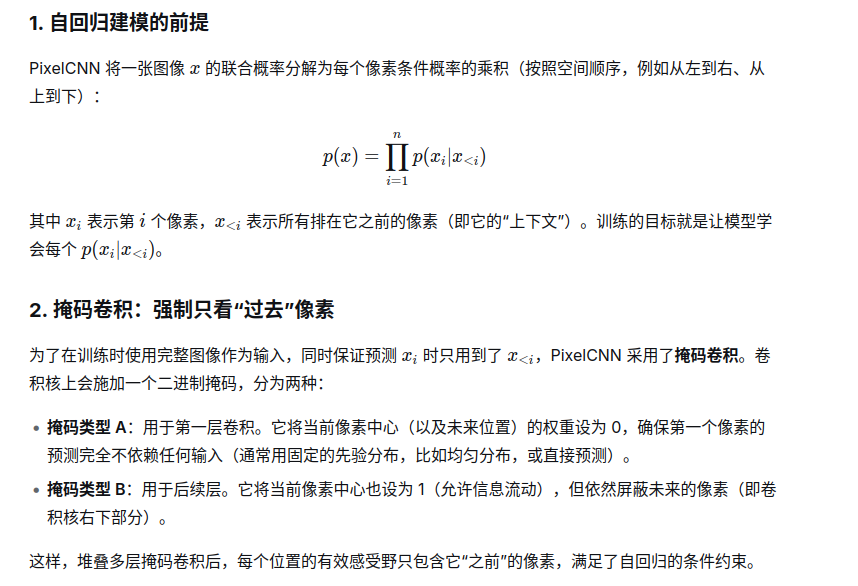

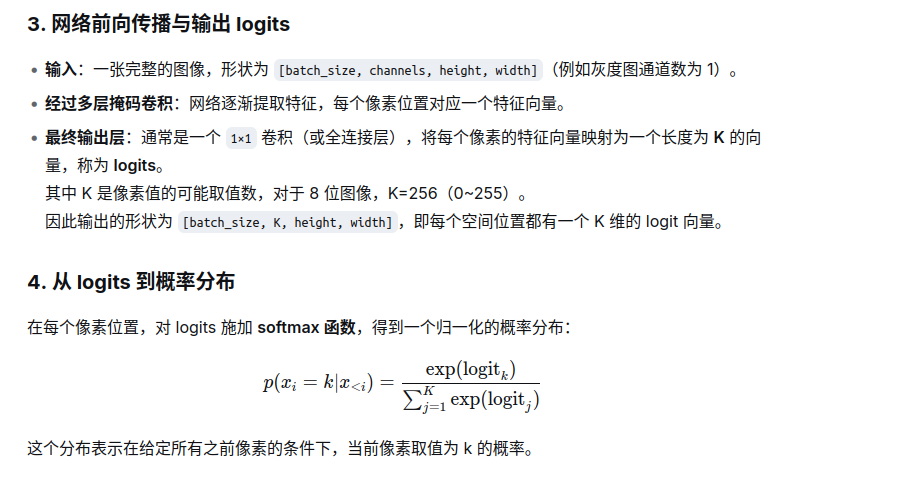

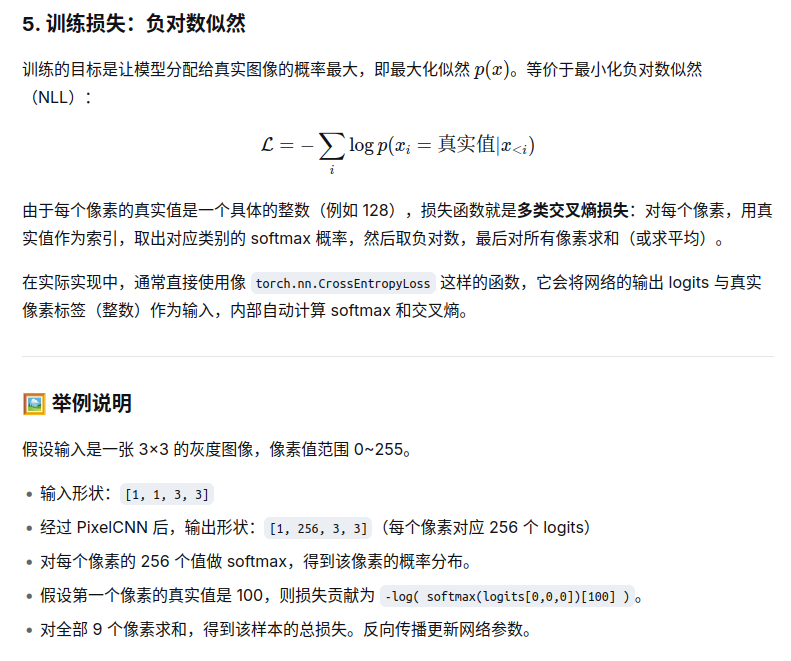

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# MaskConv2d 类：实现掩码卷积，用于 PixelCNN
class MaskConv2d(nn.Module):
    def __init__(self, conv_type, *args, **kwargs):
        super().__init__()
        # 断言 conv_type 必须是 'A' 或 'B'
        assert conv_type in ('A', 'B')
        # 创建标准的 2D 卷积层
        self.conv = nn.Conv2d(*args, **kwargs)
        # 获取卷积核的高度和宽度
        H, W = self.conv.weight.shape[-2:]
        # 初始化掩码为全零张量
        mask = torch.zeros((H, W), dtype=torch.float32)
        # 设置上半部分为 1（包括中心行上半）
        mask[0:H // 2] = 1
        # 设置中心行的左半部分为 1
        mask[H // 2, 0:W // 2] = 1
        # 如果是类型 B，允许使用中心像素
        if conv_type == 'B':
            mask[H // 2, W // 2] = 1
        # 重塑掩码以匹配卷积核形状
        mask = mask.reshape((1, 1, H, W))
        # 将掩码注册为缓冲区（不作为参数更新）
        self.register_buffer('mask', mask, False)

    def forward(self, x):
        # 将卷积权重与掩码相乘，实现掩码效果
        self.conv.weight.data *= self.mask
        # 执行卷积操作
        conv_res = self.conv(x)
        return conv_res

In [ ]:
# ResidualBlock 类：PixelCNN 中的残差块，用于增加网络深度
class ResidualBlock(nn.Module):
    def __init__(self, h, bn=True):
        super().__init__()
        # ReLU 激活函数
        self.relu = nn.ReLU()
        # 第一个 1x1 卷积，将通道数从 2*h 降到 h
        self.conv1 = nn.Conv2d(2 * h, h, 1)
        # 可选的批归一化
        self.bn1 = nn.BatchNorm2d(h) if bn else nn.Identity()
        # 掩码卷积，使用类型 B，保持通道数为 h
        self.conv2 = MaskConv2d('B', h, h, 3, 1, 1)
        # 第二个批归一化
        self.bn2 = nn.BatchNorm2d(h) if bn else nn.Identity()
        # 第三个 1x1 卷积，将通道数从 h 升到 2*h
        self.conv3 = nn.Conv2d(h, 2 * h, 1)
        # 第三个批归一化
        self.bn3 = nn.BatchNorm2d(2 * h) if bn else nn.Identity()

    def forward(self, x):
        # 保存输入用于残差连接
        residual = x
        # 第一个 ReLU
        y = self.relu(x)
        # 第一个卷积和批归一化
        y = self.conv1(y)
        y = self.bn1(y)
        # 第二个 ReLU
        y = self.relu(y)
        # 掩码卷积和批归一化
        y = self.conv2(y)
        y = self.bn2(y)
        # 第三个 ReLU
        y = self.relu(y)
        # 第三个卷积和批归一化
        y = self.conv3(y)
        y = self.bn3(y)
        # 残差连接：将输出与输入相加
        y = y + residual
        return y

In [ ]:
# PixelCNN 类：完整的 PixelCNN 模型
class PixelCNN(nn.Module):
    def __init__(self, n_blocks, h, linear_dim, bn=True, color_level=256):
        super().__init__()
        # 第一个掩码卷积层，使用类型 A，输入通道 1，输出通道 2*h
        self.conv1 = MaskConv2d('A', 1, 2 * h, 7, 1, 3)
        # 批归一化
        self.bn1 = nn.BatchNorm2d(2 * h) if bn else nn.Identity()
        # 残差块列表
        self.residual_blocks = nn.ModuleList()
        for _ in range(n_blocks):
            self.residual_blocks.append(ResidualBlock(h, bn))
        # ReLU 激活
        self.relu = nn.ReLU()
        # 第一个线性层，将通道数从 2*h 降到 linear_dim
        self.linear1 = nn.Conv2d(2 * h, linear_dim, 1)
        # 第二个线性层，保持通道数为 linear_dim
        self.linear2 = nn.Conv2d(linear_dim, linear_dim, 1)
        # 输出层，将通道数从 linear_dim 映射到 color_level（颜色级别）
        self.out = nn.Conv2d(linear_dim, color_level, 1)

    def forward(self, x):
        # 第一个卷积和批归一化
        x = self.conv1(x)
        x = self.bn1(x)
        # 通过所有残差块
        for block in self.residual_blocks:
            x = block(x)
        # ReLU 激活
        x = self.relu(x)
        # 第一个线性层和 ReLU
        x = self.linear1(x)
        x = self.relu(x)
        # 第二个线性层
        x = self.linear2(x)
        # 输出层
        x = self.out(x)
        return x

## PixelCNN前向传播：张量形状与语义

假设输入是 MNIST 的灰度图：
- 输入 `x` 形状：`[B, 1, 28, 28]`

经过各层后：
1. `conv1 (Type A, out=2h)` → `[B, 2h, 28, 28]`
2. 多个 `ResidualBlock`（通道保持 `2h`）→ `[B, 2h, 28, 28]`
3. `linear1 (1x1)` → `[B, linear_dim, 28, 28]`
4. `linear2 (1x1)` → `[B, linear_dim, 28, 28]`
5. `out (1x1)` → `[B, color_level, 28, 28]`

最后一个维度含义：每个像素位置输出 `color_level` 个logits，用于分类该像素属于哪个离散灰度等级。

### 与损失函数的对应
- 预测：`predict_y` 形状 `[B, K, H, W]`
- 标签：`y` 形状 `[B, H, W]`
- 损失：`CrossEntropyLoss(predict_y, y)`

这是 PyTorch 语义分割常见输入格式，逐像素分类在形式上与分割任务一致。

# GatedPixelCNN原理概述（详细版）

GatedPixelCNN 是 PixelCNN 的关键改进版本，核心在于两点：
1. 使用**门控激活单元**增强表示能力；
2. 将依赖建模拆分为**垂直栈（Vertical Stack）**和**水平栈（Horizontal Stack）**，减少盲区并改善信息流。

## 1. 门控机制的作用
普通 ReLU 非线性在复杂条件分布下表达能力有限。GatedPixelCNN 借鉴门控思想（类似 LSTM）：

$$
\text{gate}(a,b)=\tanh(a)\odot\sigma(b)
$$

含义：
- $\tanh(a)$ 提供候选内容；
- $\sigma(b)$ 提供 0~1 的控制门；
- 两者相乘实现“选择性通过”。

这样模型在像素条件建模时更灵活，通常生成质量更高。

## 2. 为什么拆分垂直/水平卷积
在原始掩码卷积中，感受野可能存在“信息传递低效”问题。GatedPixelCNN 通过两条分支解决：
- **垂直分支**：处理来自上方行的信息；
- **水平分支**：处理当前行左侧的信息。

并通过 `v_to_h_conv` 将垂直特征注入水平分支，从而更完整利用“过去上下文”。

## 3. A/B块在Gated结构中的意义
- 首块使用 **Type A**，保证初始层不看当前像素值；
- 后续块使用 **Type B**，允许在保持因果性的前提下复用当前位置特征并加入残差。

## 4. 本代码中的关键实现点
- `VerticalMaskConv2d`：掩掉未来“行”信息；
- `HorizontalMaskConv2d`：掩掉未来“列”信息；
- `GatedBlock`：完成垂直流、水平流、门控、残差四件事；
- `GatedPixelCNN`：`A`块 + 多个`B`块 + 输出头。

## 5. 与基础PixelCNN对比总结
- 表达能力：GatedPixelCNN 更强；
- 训练稳定性：两者都较稳定；
- 采样速度：都慢（自回归串行）；
- 生成质量：Gated 版本通常更优。

In [ ]:
# VerticalMaskConv2d 类：垂直掩码卷积，用于 GatedPixelCNN
class VerticalMaskConv2d(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__()
        # 创建标准的 2D 卷积层
        self.conv = nn.Conv2d(*args, **kwargs)
        # 获取卷积核的高度和宽度
        H, W = self.conv.weight.shape[-2:]
        # 初始化掩码为全零
        mask = torch.zeros((H, W), dtype=torch.float32)
        # 设置上半部分和中心行为 1（包括中心行）
        mask[0:H // 2 + 1] = 1
        # 重塑掩码
        mask = mask.reshape((1, 1, H, W))
        # 注册掩码缓冲区
        self.register_buffer('mask', mask, False)

    def forward(self, x):
        # 应用掩码到卷积权重
        self.conv.weight.data *= self.mask
        # 执行卷积
        conv_res = self.conv(x)
        return conv_res

In [ ]:
# HorizontalMaskConv2d 类：水平掩码卷积，用于 GatedPixelCNN
class HorizontalMaskConv2d(nn.Module):
    def __init__(self, conv_type, *args, **kwargs):
        super().__init__()
        # 断言 conv_type 为 'A' 或 'B'
        assert conv_type in ('A', 'B')
        # 创建卷积层
        self.conv = nn.Conv2d(*args, **kwargs)
        # 获取高度和宽度
        H, W = self.conv.weight.shape[-2:]
        # 初始化掩码
        mask = torch.zeros((H, W), dtype=torch.float32)
        # 设置中心行的左半部分为 1
        mask[H // 2, 0:W // 2] = 1
        # 如果是类型 B，允许使用中心像素
        if conv_type == 'B':
            mask[H // 2, W // 2] = 1
        # 重塑掩码
        mask = mask.reshape((1, 1, H, W))
        # 注册缓冲区
        self.register_buffer('mask', mask, False)

    def forward(self, x):
        # 应用掩码
        self.conv.weight.data *= self.mask
        # 执行卷积
        conv_res = self.conv(x)
        return conv_res

In [ ]:
# GatedBlock 类：GatedPixelCNN 中的门控块
class GatedBlock(nn.Module):
    def __init__(self, conv_type, in_channels, p, bn=True):
        super().__init__()
        self.conv_type = conv_type
        self.p = p
        # 垂直卷积，将输入通道 in_channels 映射到 2*p
        self.v_conv = VerticalMaskConv2d(in_channels, 2 * p, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(2 * p) if bn else nn.Identity()
        # 从垂直到水平的 1x1 卷积
        self.v_to_h_conv = nn.Conv2d(2 * p, 2 * p, 1)
        self.bn2 = nn.BatchNorm2d(2 * p) if bn else nn.Identity()
        # 水平卷积，使用指定的类型
        self.h_conv = HorizontalMaskConv2d(conv_type, in_channels, 2 * p, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(2 * p) if bn else nn.Identity()
        # 水平输出卷积，将通道数从 p 映射到 p
        self.h_output_conv = nn.Conv2d(p, p, 1)
        self.bn4 = nn.BatchNorm2d(p) if bn else nn.Identity()

    def forward(self, v_input, h_input):
        # 垂直卷积和批归一化
        v = self.v_conv(v_input)
        v = self.bn1(v)
        # 从垂直输出到水平输入：去掉最后一行，并填充一行在顶部
        v_to_h = v[:, :, 0:-1]
        v_to_h = F.pad(v_to_h, (0, 0, 1, 0))
        # 1x1 卷积和批归一化
        v_to_h = self.v_to_h_conv(v_to_h)
        v_to_h = self.bn2(v_to_h)

        # 垂直门控：分割为两部分，使用 tanh 和 sigmoid
        v1, v2 = v[:, :self.p], v[:, self.p:]
        v1 = torch.tanh(v1)
        v2 = torch.sigmoid(v2)
        v = v1 * v2

        # 水平卷积和批归一化
        h = self.h_conv(h_input)
        h = self.bn3(h)
        # 添加垂直到水平的连接
        h = h + v_to_h
        # 水平门控
        h1, h2 = h[:, :self.p], h[:, self.p:]
        h1 = torch.tanh(h1)
        h2 = torch.sigmoid(h2)
        h = h1 * h2
        # 水平输出卷积和批归一化
        h = self.h_output_conv(h)
        h = self.bn4(h)
        # 如果是类型 B，添加残差连接
        if self.conv_type == 'B':
            h = h + h_input
        return v, h

In [ ]:
# GatedPixelCNN 类：完整的 GatedPixelCNN 模型
class GatedPixelCNN(nn.Module):
    def __init__(self, n_blocks, p, linear_dim, bn=True, color_level=256):
        super().__init__()
        # 第一个门控块，使用类型 A
        self.block1 = GatedBlock('A', 1, p, bn)
        # 后续的门控块列表，使用类型 B
        self.blocks = nn.ModuleList()
        for _ in range(n_blocks):
            self.blocks.append(GatedBlock('B', p, p, bn))
        # ReLU 激活
        self.relu = nn.ReLU()
        # 第一个线性层，将通道数从 p 映射到 linear_dim
        self.linear1 = nn.Conv2d(p, linear_dim, 1)
        # 第二个线性层
        self.linear2 = nn.Conv2d(linear_dim, linear_dim, 1)
        # 输出层
        self.out = nn.Conv2d(linear_dim, color_level, 1)

    def forward(self, x):
        # 第一个块，输入 v 和 h 都是 x
        v, h = self.block1(x, x)
        # 通过所有后续块
        for block in self.blocks:
            v, h = block(v, h)
        # ReLU 激活
        x = self.relu(h)
        # 第一个线性层和 ReLU
        x = self.linear1(x)
        x = self.relu(x)
        # 第二个线性层
        x = self.linear2(x)
        # 输出层
        x = self.out(x)
        return x

## GatedBlock内部数据流（逐步拆解）

以一次 `forward(v_input, h_input)` 为例：

1. **垂直路径**：
   - `v = v_conv(v_input)`
   - 做 BN 后得到垂直上下文特征。

2. **垂直到水平的信息注入**：
   - `v_to_h = v[:, :, 0:-1]` 去掉最后一行；
   - `pad` 在顶部补回一行，保持空间尺寸；
   - 通过 `1x1 conv` 对齐到水平分支通道。

3. **垂直门控**：
   - 把通道一分为二：`v1, v2`；
   - `tanh(v1) * sigmoid(v2)` 得到门控后的垂直输出。

4. **水平路径**：
   - `h = h_conv(h_input)` 后做 BN；
   - 融合 `v_to_h`（关键跨分支连接）。

5. **水平门控与输出投影**：
   - 同样做 `tanh * sigmoid`；
   - 通过 `h_output_conv` 压缩到 `p` 通道；
   - Type B 块再加残差 `h + h_input`。

该结构使模型既能看“上方历史”，又能细致建模“同一行左侧历史”。

# 使用和训练指南（实战详细版）

下面这部分告诉你：**如何从零训练、如何采样、如何判断训练是否正常、如何加速实验**。

## 1. 环境与依赖
建议环境：
- Python 3.9+
- PyTorch 2.x
- torchvision
- einops
- opencv-python
- numpy

可用命令：
```bash
pip install torch torchvision einops opencv-python numpy
```

## 2. 数据与离散化
PixelCNN 在这里把像素值离散成 `color_level` 个类别：
- 输入图像 `x` 范围为 $[0,1]$；
- 标签构造为 `ceil(x * (color_level - 1))`；
- 训练目标变成逐像素分类。

`color_level` 越高，表达更细腻，但分类难度和计算量也增加。

## 3. 关键超参数建议
- `batch_size=128`：GPU 显存不够可降到 64/32；
- `n_epochs=10`：仅演示，实际通常需要 40+；
- `lr=1e-3`：常见起点，若震荡可降到 `3e-4`；
- `n_blocks=15, h/p=128`：是质量与速度折中配置。

## 4. 训练流程（你将执行的步骤）
1. 先运行模型定义单元；
2. 运行“导入与数据加载”单元；
3. 运行 `train_model` 函数单元；
4. 运行 `sample_images` 函数单元；
5. 最后运行主执行单元完成训练与采样。

## 5. 训练正常的信号
- 每个 epoch 平均 loss 逐步下降；
- 采样图像从噪声逐渐出现数字轮廓；
- 不出现 `nan`、loss 爆炸、长期不下降。

## 6. 采样注意事项
采样是逐像素循环，速度会明显慢于训练（尤其 CPU）。
- 若只是验证流程，先用 `n_sample=16`；
- 若追求展示效果，再提升到 `n_sample=81`；
- 可先训练少量 epoch 做 smoke test，再长训。

## 7. 输出文件位置
- 权重：`work_dirs/{model_name}_{color_level}.pth`
- 采样图：`work_dirs/generated_{model_name}_{color_level}.jpg`

如果输出图几乎全黑或全白，优先检查：
- `color_level` 是否太低；
- 训练是否足够；
- 标签离散化与输出类别数是否匹配。

In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import einops
import numpy as np
import cv2

# 设置参数
batch_size = 128
color_level = 8  # 可以设置为2到256之间的任何值
n_epochs = 10  # 为演示简化epoch数，实际训练可能需要更多
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 数据预处理：将图像归一化到[0,1]
transform = transforms.Compose([
    transforms.ToTensor(),  # 转换为张量并归一化到[0,1]
])

# 加载MNIST数据集
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True)

print(f"数据集大小: {len(train_dataset)}")
print(f"图像形状: {train_dataset[0][0].shape}")

In [ ]:
def train_model(model, model_path):
    """
    训练PixelCNN模型
    Args:
        model: 要训练的模型
        model_path: 模型保存路径
    """
    model = model.to(device)
    # 使用Adam优化器，学习率1e-3
    optimizer = torch.optim.Adam(model.parameters(), 1e-3)
    # 交叉熵损失函数
    loss_fn = nn.CrossEntropyLoss()

    print("开始训练...")
    tic = time.time()
    model.train()  # 设置为训练模式

    for epoch in range(n_epochs):
        total_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            current_batch_size = x.shape[0]
            x = x.to(device)

            # 将像素值从[0,1]映射到离散级别[0, color_level-1]
            y = torch.ceil(x * (color_level - 1)).long()
            y = y.squeeze(1)  # 移除通道维度，因为是灰度图

            # 前向传播
            predict_y = model(x)

            # 计算损失：预测的是每个像素的概率分布
            loss = loss_fn(predict_y, y)

            # 反向传播和优化
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * current_batch_size

            # 每100个batch打印一次进度
            if batch_idx % 100 == 0:
                print(f'Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.4f}')

        # 计算平均损失
        avg_loss = total_loss / len(train_dataset)
        toc = time.time()

        # 保存模型
        torch.save(model.state_dict(), model_path)
        print(f'Epoch {epoch} 完成，平均损失: {avg_loss:.4f}, 耗时: {(toc - tic):.2f}s')

    print('训练完成!')

## 训练结果解读与监控指标

为了判断训练是否“真正在学”，建议同时观察以下指标：

### 1. 训练损失（主指标）
- 理想情况：整体下降，后期缓慢收敛；
- 异常情况：
  - 持续不降：学习率过高/过低、模型容量不足、数据预处理异常；
  - 出现 `nan`：学习率过大、混合精度不稳定、梯度爆炸。

### 2. 定性可视化（强建议）
每隔若干 epoch 采样一次，观察数字结构是否逐渐清晰：
- 早期：噪声块状；
- 中期：出现笔画趋势；
- 后期：可辨认数字。

### 3. 推荐增加的工程监控（可选）
- 记录每 epoch 用时（估算训练总时长）；
- 记录显存占用（避免 OOM）；
- 保存最佳权重（按验证集或采样质量）。

### 4. 为什么只看loss不够
PixelCNN 优化的是逐像素分类目标，loss 下降并不总是直接对应“视觉质量最佳”，因此最好结合采样图一起判断。

In [ ]:
def sample_images(model, model_path, output_path, n_sample=81):
    """
    使用训练好的模型生成新图像
    Args:
        model: 模型实例
        model_path: 模型权重路径
        output_path: 输出图像保存路径
        n_sample: 生成图像数量
    """
    model.eval()  # 设置为评估模式
    # 加载训练好的权重
    model.load_state_dict(torch.load(model_path))
    model = model.to(device)

    # MNIST图像尺寸是28x28
    C, H, W = 1, 28, 28
    # 初始化全零图像
    x = torch.zeros((n_sample, C, H, W)).to(device)

    print("开始采样...")
    with torch.no_grad():
        # 逐像素生成
        for i in range(H):
            for j in range(W):
                # 前向传播获取每个像素的预测
                output = model(x)
                # 获取当前位置的概率分布
                prob_dist = F.softmax(output[:, :, i, j], -1)
                # 从概率分布中采样
                pixel = torch.multinomial(prob_dist, 1).float() / (color_level - 1)
                # 将采样值赋给图像
                x[:, :, i, j] = pixel

    # 将图像从[0,1]转换为[0,255]
    imgs = x * 255
    imgs = imgs.clamp(0, 255)
    # 将多个图像排列成网格
    imgs = einops.rearrange(imgs,
                            '(b1 b2) c h w -> (b1 h) (b2 w) c',
                            b1=int(n_sample**0.5))

    # 转换为numpy数组并保存
    imgs = imgs.detach().cpu().numpy().astype(np.uint8)
    cv2.imwrite(output_path, imgs)
    print(f"采样完成，图像保存到: {output_path}")

## 采样的随机性和“想要的图像”能否生成？

PixelCNN 生成图像的过程本质上是**随机采样**：每个像素都是根据模型预测的概率分布 `p(x_{i,j}|x_{<i,j})` 采样得到的。

### 1. 为什么是随机的？
- 模型输出的是每个像素对每个灰度值的概率（softmax分布）。
- 采样时，我们从该概率分布中抽取一个值（`torch.multinomial`），因此每次生成都可能不同。

### 2. 怎么才能“控制”生成内容？
- **固定随机种子**：让多次采样结果可复现，但仍然是随机样本。
- **条件生成**（最有效）：在生成过程中，先固定一部分像素（例如左上角或某些掩码区域），再让模型生成剩余像素，这样输出就会“遵循”你固定的部分。
- **修改输入初始状态**：理论上可以先把空图像中一些位置填入你希望的内容，并只对剩余位置采样。

### 3. 这样能生成“我想要的图像”吗？
PixelCNN 不是直接“按文字描述生成”或“按指定风格生成”，它是一个**概率模型**：
- 它学的是训练数据的分布。
- 如果你希望输出“某种特定图像”，最直接的方式是让模型看到一部分你想要的像素（条件生成），让其补全剩余部分。

因此，**生成过程本质上是随机的，但可以通过设置条件（给定部分像素）来让生成结果更符合预期**。

## 训练时是否要做“分类”？如何生成特定数字？

当前 notebook 中的 PixelCNN 是**无条件模型（unconditional）**，也就是说：
- 训练时用的是所有手写数字图像（0-9）一起训练；
- 生成时对图像没有任何类别“提示”，因此输出会随机覆盖所有数字的分布（容易出现任何数字）。

> **只用某一类数据训练**（例如只用“1”训练），模型会学到“所有样本都是1”的分布，因此它会主要生成类似1的图像。**这也是一种可行的做法**，但需要为每个数字都训练一个模型。

### ✅ 想要模型根据类别生成（更智能）——“条件生成”
更常见的做法是：训练时让模型同时学习图像 + 类别条件，在生成时传入“想要的类别”即可。这个思路叫 **类条件生成（class-conditional generation）**。

实现方式通常有两种：
1. **直接按类别训练多份模型**（每个类别一份） → 简单但效率低；
2. **在模型中加入类别条件（class embedding / one-hot）** → 推荐方式，训练一次即可支持多类生成。

### 示意（条件 PixelCNN）
在模型里加一个类别向量 `y_cond`，让网络在每次前向时都能看到类别信息（可以在卷积前加到特征里，或作为卷积偏置）：

```python
class ConditionalPixelCNN(PixelCNN):
    def __init__(self, num_classes, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_embed = nn.Embedding(num_classes, 128)
        # 这个 128 可以和你的网络通道数对齐

    def forward(self, x, class_idx):
        # class_idx: shape [B]
        embed = self.class_embed(class_idx)         # [B, 128]
        embed = embed[:, :, None, None]             # [B, 128, 1, 1]
        x = x + embed                              # 简单地加在输入上
        return super().forward(x)
```

训练时就把对应标签 `class_idx` (0-9) 输入模型；
生成时指定 `class_idx=1`，就会倾向生成“数字1”。

> 注意：要让条件信息真正影响输出，模型结构中需要在多个层次注入类别信息（比如每层都加上 embedding 或通过条件批归一化）。上面的示例仅用于说明思路。

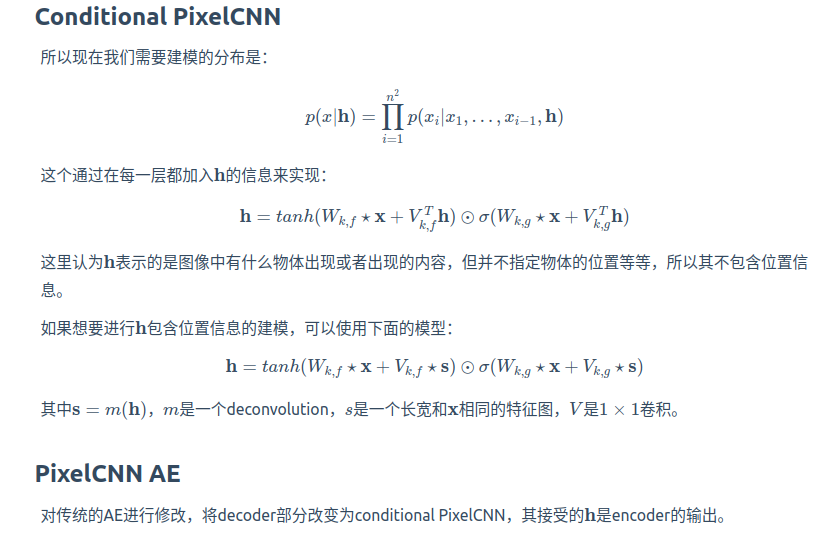

# Conditional PixelCNN: 原理与最小实现

## 1. 原理概述
无条件的 PixelCNN 建模的是联合概率 $p(\mathbf{x}) = \prod_i p(x_i \mid x_{<i})$，它只能随机生成训练集分布内的随机图像。而 **条件 PixelCNN（Conditional PixelCNN）** 引入了额外的控制信息（例如类别标签 $h$），它建模的是条件概率分布：
$$
p(\mathbf{x} \mid h) = \prod_{i=1}^{H\times W} p(x_i \mid x_{<i}, h)
$$

**核心思想：通过将条件向量（如类别 Embedding）融入到网络的中间特征图中，引导模型按照指定条件生成对应的像素分布。**

## 2. 条件注入方式（Injection Mechanism）
在代码实现上，我们通常通过特征叠加来融合条件信息：
1. **类别嵌入（Embedding）**：首先将离散的类别标签（如数字 $0\sim9$）通过 `nn.Embedding` 转化为连续的特征向量（例如长度为 `embed_dim` 的向量）。
2. **空间广播（Spatial Broadcast）**：使用线性层 `nn.Linear` 或 $1\times 1$ 卷积，将特征向量的维度映射为与当前图像特征图对应的通道数，并在空间维度（高和宽 $H, W$）上进行广播（Broadcast），比如将形状变为 `[B, C, 1, 1]` 的特征张量。
3. **特征偏置（Feature Bias）**：将条件张量直接相加在卷积层的输出特征图上：
   $$
   H^{\text{new}} = \text{Activation}(\text{Conv}(H^{\text{old}}) + \text{Project}(h))
   $$
   通过在多个残差块中反复注入这一条件，网络模型在每一步预测像素点时，都可以“看见”当前的生成提示，从而生成更符合用户预期的类别图像。

In [ ]:
import torch
import torch.nn as nn

# 假设此前的 MaskConv2d 已经定义

class ConditionalResidualBlock(nn.Module):
    """带条件向量注入的残差块"""
    def __init__(self, h, embed_dim, bn=True):
        super().__init__()
        self.relu = nn.ReLU()
        self.conv1 = nn.Conv2d(2 * h, h, 1)
        self.bn1 = nn.BatchNorm2d(h) if bn else nn.Identity()
        self.conv2 = MaskConv2d('B', h, h, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(h) if bn else nn.Identity()
        self.conv3 = nn.Conv2d(h, 2 * h, 1)
        self.bn3 = nn.BatchNorm2d(2 * h) if bn else nn.Identity()
        
        # 核心映射层：将条件向量映射到当前卷积通道数 h
        self.cond_proj = nn.Linear(embed_dim, h)

    def forward(self, x, cond_embed):
        residual = x
        y = self.relu(x)
        y = self.conv1(y)
        y = self.bn1(y)
        
        # ========== 条件注入的核心步骤 ==========
        # 将 [B, embed_dim] 的条件映为 [B, h]，再 reshape 为 [B, h, 1, 1]
        proj_cond = self.cond_proj(cond_embed).unsqueeze(-1).unsqueeze(-1)
        # 将条件特征作为偏置加在当前特征图上 (在空间维度广播 H, W)
        y = y + proj_cond 
        # ========================================
        
        y = self.relu(y)
        y = self.conv2(y)
        y = self.bn2(y)
        y = self.relu(y)
        y = self.conv3(y)
        y = self.bn3(y)
        return y + residual

class ConditionalPixelCNN(nn.Module):
    """可指定类别的条件 PixelCNN"""
    def __init__(self, n_blocks, h, linear_dim, num_classes=10, embed_dim=32, bn=True, color_level=256):
        super().__init__()
        self.num_classes = num_classes
        # 1. 类别 Embedding 层：将类别 0-9 映射为 embed_dim 维的连续特征向量
        self.class_embedding = nn.Embedding(num_classes, embed_dim) 
        
        self.conv1 = MaskConv2d('A', 1, 2 * h, 7, 1, 3)
        self.bn1 = nn.BatchNorm2d(2 * h) if bn else nn.Identity()
        
        # 2. 将条件传入所有的残差块中
        self.residual_blocks = nn.ModuleList([
            ConditionalResidualBlock(h, embed_dim, bn) for _ in range(n_blocks)
        ])
        
        self.relu = nn.ReLU()
        self.linear1 = nn.Conv2d(2 * h, linear_dim, 1)
        self.linear2 = nn.Conv2d(linear_dim, linear_dim, 1)
        self.out = nn.Conv2d(linear_dim, color_level, 1)

    def forward(self, x, labels):
        # 提取当前 Batch 中各个图像对应的类别条件向量: Shape [B, embed_dim]
        cond_embed = self.class_embedding(labels) 
        
        x = self.conv1(x)
        x = self.bn1(x)
        
        # 在网络前向传播时，逐层向各个 ResidualBlock 注入条件信息
        for block in self.residual_blocks:
            x = block(x, cond_embed)
            
        x = self.relu(x)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.out(x)
        return x

# ======================= 模型测试及前向计算演示 =======================
if __name__ == '__main__':
    batch_size = 4
    channels, height, width = 1, 28, 28
    
    # 模拟 MNIST 等效输入和随机标签
    dummy_x = torch.randn(batch_size, channels, height, width)
    dummy_labels = torch.randint(0, 10, (batch_size,)) # 生成类别 0~9 的随机 Label
    
    # 实例化 ConditionalPixelCNN
    cond_model = ConditionalPixelCNN(
        n_blocks=5, 
        h=64, 
        linear_dim=32, 
        num_classes=10, 
        embed_dim=32
    )
    
    # 前向传播需要同时提供【图像张量】和【条件标签】
    output = cond_model(dummy_x, dummy_labels)
    
    print("====== Conditional PixelCNN 测试 ======")
    print(f"输入预测图像的维度    (dummy_x): {list(dummy_x.shape)}")
    print(f"输入类别条件的维度    (labels) : {list(dummy_labels.shape)}")
    print(f"输出概率分类图的维度  (output) : {list(output.shape)}")
    print("=======================================")